# Boca Juniors 2026 — Análisis de datos y modelo predictivo

**Autor:** Gonzalo Chiaravalle
**Última actualización:** 23 de julio de 2026

Proyecto de portfolio: seguimiento de la temporada 2026 de Boca Juniors,
impacto de los refuerzos, contexto de lesiones y un modelo predictivo simple
(estilo Poisson/Dixon-Coles) calibrado con datos reales de xG y fuerza de
cada rival.

**Fuentes:** FBref (StatsPerform), BocaStats, Sofascore, FotMob, FootyStats,
Transfermarkt, Wikipedia y prensa deportiva.

**Índice**
1. Carga de datos
2. Contexto del semestre (refuerzos, lesiones, cambio de DT)
3. Forma del equipo
4. Local vs. visitante (el hallazgo clave)
5. Goleadores, asistencias y eficiencia
6. ¿Cuándo marca Boca? (minuto de los goles)
7. Eficiencia de tiro: a favor vs. en contra
8. Disciplina (tarjetas)
9. Impacto de los refuerzos
10. Modelo predictivo: próximos 15 partidos
11. Conclusiones y próximos pasos


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

pd.set_option("display.width", 120)
plt.rcParams["figure.facecolor"] = "white"
BOCA_BLUE = "#0057A8"
BOCA_YELLOW = "#F2C300"
BOCA_RED = "#E63946"
BOCA_GREEN = "#2A9D8F"


: 

## 1. Carga de datos

In [ ]:
matches = pd.read_csv("data/matches.csv", parse_dates=["date"])
transfers = pd.read_csv("data/transfers.csv", parse_dates=["arrival_date"])
squad = pd.read_csv("data/squad.csv")
injuries = pd.read_csv("data/injuries.csv", parse_dates=["since"])
fixture = pd.read_csv("data/fixture_clausura.csv", parse_dates=["date"])
standings = pd.read_csv("data/standings_tabla_anual.csv")
xg_split = pd.read_csv("data/team_xg_home_away.csv").set_index("split")

# Datasets nuevos (FBref + Wikipedia oficial)
goals_official = pd.read_csv("data/goals_official_wikipedia.csv")
assists_official = pd.read_csv("data/assists_official_wikipedia.csv")
cards_official = pd.read_csv("data/cards_official_wikipedia.csv")
goalkeepers_official = pd.read_csv("data/goalkeepers_official_wikipedia.csv")
competition_summary = pd.read_csv("data/competition_summary.csv")
goals_by_match = pd.read_csv("data/goals_by_match.csv", parse_dates=["date"])
matches_shooting = pd.read_csv("data/matches_shooting.csv", parse_dates=["date"])
fbref_players = pd.read_csv("data/fbref_player_summary.csv")
coach_comparison = pd.read_csv("data/coach_comparison.csv")

played = matches.dropna(subset=["result"]).copy().sort_values("date").reset_index(drop=True)
print(f"Partidos jugados cargados: {len(played)}")
print(f"Goles individuales registrados (Goal Log FBref): {len(goals_by_match)}")
print(f"Jugadores en plantel: {len(squad)}")
print(f"Refuerzos 2026: {len(transfers)}")
print(f"Lesiones activas/recientes: {len(injuries)}")


: 

## 2b. Los datos de cada ciclo, contados por separado

No tiene sentido "comparar" a Úbeda con Arruabarrena todavía — 3 partidos
(uno amistoso) es una muestra minúscula frente a los 24 de Úbeda. En vez de
eso, contamos los datos de cada uno por su lado, y vamos marcando los
cambios que empiecen a notarse a medida que haya más partidos de fondo.


In [3]:
print("CON CLAUDIO UBEDA (25/01 al 02/06) — 24 partidos")
u = coach_comparison[coach_comparison["coach"] == "Claudio Ubeda"].iloc[0]
print(f"  {int(u.w)} victorias, {int(u.d)} empates, {int(u.l)} derrotas")
print(f"  {int(u.gf)} goles a favor, {int(u.ga)} en contra ({u.gf_per_pj:.2f} / {u.ga_per_pj:.2f} por partido)")

print("\nCON RODOLFO ARRUABARRENA (desde el 18/06) — 3 partidos hasta ahora")
a = coach_comparison[coach_comparison["coach"] == "Rodolfo Arruabarrena"].iloc[0]
print(f"  {int(a.w)} victorias, {int(a.d)} empates, {int(a.l)} derrotas")
print(f"  {int(a.gf)} goles a favor, {int(a.ga)} en contra")
print("  Partidos: amistoso vs Paranaense (1-0), Copa Argentina vs Sarmiento (2-0),")
print("  ida de Copa Sudamericana vs O'Higgins (1-0). Ninguno de liga todavia.")

print("\nTodavia no hay base suficiente para sacar conclusiones sobre el nuevo ciclo -")
print("el primer dato realmente comparable llega el 26/07 con el debut en el Clausura.")


CON CLAUDIO UBEDA (25/01 al 02/06) — 24 partidos
  11 victorias, 7 empates, 6 derrotas
  32 goles a favor, 17 en contra (1.33 / 0.71 por partido)

CON RODOLFO ARRUABARRENA (desde el 18/06) — 3 partidos hasta ahora
  3 victorias, 0 empates, 0 derrotas
  4 goles a favor, 0 en contra
  Partidos: amistoso vs Paranaense (1-0), Copa Argentina vs Sarmiento (2-0),
  ida de Copa Sudamericana vs O'Higgins (1-0). Ninguno de liga todavia.

Todavia no hay base suficiente para sacar conclusiones sobre el nuevo ciclo -
el primer dato realmente comparable llega el 26/07 con el debut en el Clausura.


## 2c. Vista previa: la vuelta ante O'Higgins (30/07)

Boca ganó la ida 1-0 en la Bombonera con gol de Merentiel (asistencia de
Paredes). Con los datos de ese partido, más los dos anteriores del ciclo
Arruabarrena, armamos una lectura de cómo podría venir la vuelta.


In [4]:
ohiggins_stats = pd.read_csv("data/ohiggins_leg1_match_stats.csv")
ohiggins_players = pd.read_csv("data/ohiggins_leg1_player_stats.csv")

print("ESTADISTICAS DEL PARTIDO DE IDA (Boca 1 - 0 O'Higgins)")
print(ohiggins_stats.to_string(index=False))

print("\nJugadores de Boca con mas participacion ofensiva (ida):")
top_ofensivos = ohiggins_players.sort_values("shots", ascending=False).head(6)
print(top_ofensivos[["name", "position", "minutes", "shots", "shots_on_target", "goals", "assists"]].to_string(index=False))


ESTADISTICAS DEL PARTIDO DE IDA (Boca 1 - 0 O'Higgins)
             metric  boca  ohiggins
     possession_pct  59.0      41.0
              shots  15.0      10.0
    shots_on_target   2.0       3.0
shots_on_target_pct  13.3      30.0
              saves   3.0       1.0
           save_pct 100.0      50.0
              fouls  11.0      11.0
            crosses  28.0      10.0
      interceptions  14.0       9.0
           offsides   1.0       1.0
       yellow_cards   0.0       1.0

Jugadores de Boca con mas participacion ofensiva (ida):
            name position  minutes  shots  shots_on_target  goals  assists
 Leandro Paredes       MF       90      3                0      0        1
 Sebastian Villa       FW       89      3                0      0        0
  Dylan Gorosito       DF       77      2                0      0        0
   Leonel Flores       FW       77      2                0      0        0
    Alan Velasco       FW       13      2                1      0        0
Miguel

**Lectura de los datos + algunas ideas propias:**

- **Boca dominó la posesión (59%) pero definió poco** (2 tiros al arco en 15
  intentos, 13.3%) — un patrón que ya veníamos viendo en la temporada
  (ver sección 8, eficiencia de tiro). Si la vuelta se pone pareja, la
  definición otra vez va a ser la clave.
- **Sebastián Villa debutó de titular** y jugó 89 minutos con 3 remates —
  ninguno al arco, pero fue el jugador de campo con más intentos después
  de Merentiel. Para la vuelta, si mejora la puntería, puede ser la
  diferencia ante un equipo que va a necesitar arriesgar.
- **Montero sumó su segundo partido en el arco sin recibir goles** (3
  atajadas, 100% de efectividad) — con Marchesín afuera todo el año, cada
  partido limpio suma puntos a favor de Montero como titular indiscutido.
- **Leandro Paredes fue el motor del equipo**: 3 remates, la asistencia del
  gol, y el que más centros/pases largos intentó. Con el resultado a favor,
  va a ser clave que controle los tiempos del partido de vuelta.
- **Nuestra lectura:** con el 1-0 a favor, Boca puede permitirse un
  partido más cauto de visitante — algo que, según el hallazgo de la
  página anterior (Boca rinde MEJOR de visitante que de local esta
  temporada), en realidad podría jugar a favor del equipo en Rancagua.
  O'Higgins va a tener que ir a buscar el partido, lo que abre espacios
  para las transiciones rápidas de Villa y Merentiel.

*Esto es una lectura basada en los datos disponibles al momento de escribir
esto (partido de ida) — no una predicción cerrada. La idea es que sirva
como ejercicio de análisis pre-partido, el tipo de trabajo que se hace en
un área de scouting/analytics antes de cada cruce.*


## 2. Contexto del semestre

Tres cambios grandes y simultáneos hay que tener en cuenta antes de sacar
conclusiones apuradas sobre "qué mejora el rendimiento":

1. **Cambio de entrenador**: Claudio Úbeda (hasta el 2 de junio) fue
   reemplazado por Rodolfo Arruabarrena (desde el 18 de junio), tras la
   eliminación en fase de grupos de la Copa Libertadores — algo que no le
   pasaba a Boca desde 1994.
2. **Refuerzos**: Ascacíbar y Bareiro llegaron antes del arranque de
   temporada (verano, $4M y $3M respectivamente); Lozano, Montero y Villa
   llegaron en las últimas semanas (invierno).
3. **Lesiones**: Marchesín está afuera hasta fin de año (rotura de
   ligamento cruzado) — por eso llegó Montero. Además, en la semana del
   19-20/07 se lesionaron 5 jugadores de campo (Lozano, Belmonte, Palacios,
   Giménez, Bareiro), justo al arrancar el ciclo Arruabarrena.


In [5]:
print("RESUMEN POR COMPETENCIA (temporada 2026)")
print(competition_summary.to_string(index=False))

print("\nREFUERZOS 2026")
print(transfers[["player", "position", "arrival_date", "fee_usd_million", "previous_club"]]
      .sort_values("arrival_date").to_string(index=False))

print("\nLESIONES ACTIVAS / RECIENTES")
print(injuries[["player", "injury", "since", "days_out"]].to_string(index=False))


RESUMEN POR COMPETENCIA (temporada 2026)
      competition first_match last_match  pj  pg  pe  pp  gf  gc  dg  pts  efectividad_pct                           status
  Torneo Apertura  2026-01-25 2026-05-09  17   8   6   3  24  12  12 30.0            58.82                  Octavofinalista
  Torneo Clausura         NaN        NaN   0   0   0   0   0   0   0  0.0             0.00                     Por disputar
   Copa Argentina  2026-02-24        NaN   2   2   0   0   4   0   4  6.0           100.00                  32avos superado
Copa Libertadores  2026-04-07 2026-05-28   6   2   1   3   6   5   1  7.0            38.89       Fase de grupos (eliminado)
Copa Sudamericana  2026-07-23        NaN   0   0   0   0   0   0   0  0.0             0.00          Eliminatoria de octavos
        Amistosos  2026-01-14 2026-07-08   3   2   1   0   3   1   2  NaN            66.67 No cuenta para el record oficial

REFUERZOS 2026
            player position arrival_date  fee_usd_million           previou

## 3. Forma del equipo a lo largo de la temporada

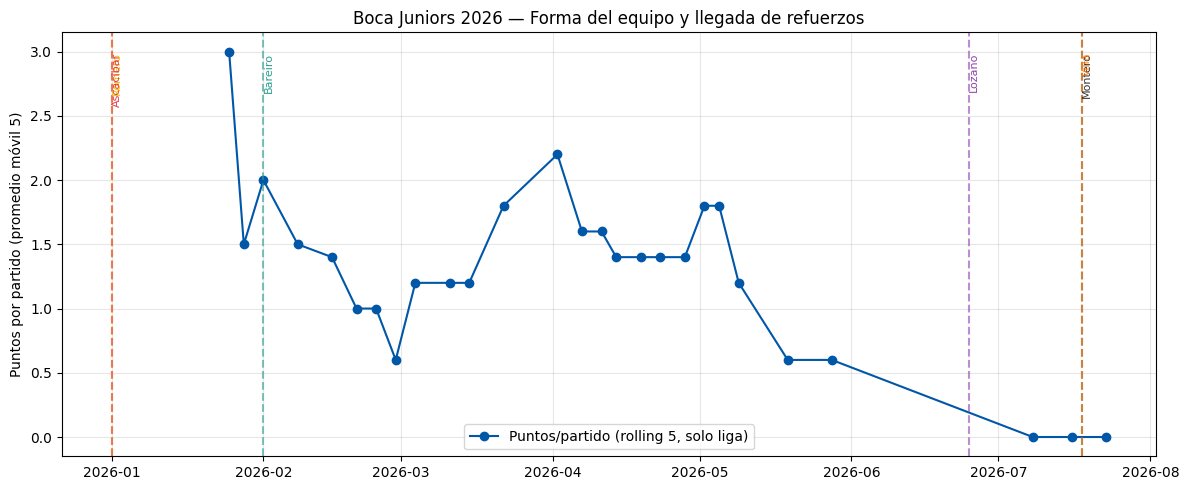

Nota: el promedio móvil solo cuenta puntos de LIGA (0 en partidos de copa/amistoso),
por eso la caída de julio exagera un poco la crisis real del equipo.


In [6]:
played["points_num"] = played["points"].fillna(0)
played["rolling_points_5"] = played["points_num"].rolling(5, min_periods=1).mean()
played["goal_diff"] = played["goals_for"] - played["goals_against"]
played["rolling_gd_5"] = played["goal_diff"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(played["date"], played["rolling_points_5"], marker="o", color=BOCA_BLUE,
        label="Puntos/partido (rolling 5, solo liga)")
ax.set_ylabel("Puntos por partido (promedio móvil 5)")
ax.set_title("Boca Juniors 2026 — Forma del equipo y llegada de refuerzos")

colors = ["#F2C300", "#E63946", "#2A9D8F", "#8E44AD", "#333333", "#FF7F0E"]
for idx, (_, t) in enumerate(transfers.sort_values("arrival_date").iterrows()):
    ax.axvline(t["arrival_date"], linestyle="--", alpha=0.6, color=colors[idx % len(colors)])
    ax.text(t["arrival_date"], ax.get_ylim()[1]*0.95, t["player"].split()[-1],
            rotation=90, fontsize=8, va="top", color=colors[idx % len(colors)])

ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("Nota: el promedio móvil solo cuenta puntos de LIGA (0 en partidos de copa/amistoso),")
print("por eso la caída de julio exagera un poco la crisis real del equipo.")


## 4. El hallazgo más interesante: rendimiento local vs. visitante

Los datos de FootyStats muestran algo atípico: **Boca rinde mejor de
visitante que de local esta temporada** — 63% de partidos ganados de
visitante contra apenas 33% de local ("ventaja local" de **-8%**, cuando
lo normal es que sea positiva). El resumen de temporada de FBref lo
confirma: **Local 3-5-0 (14 pts) vs. Visitante 5-1-2 (16 pts)** — más
puntos de visitante jugando dos partidos menos.


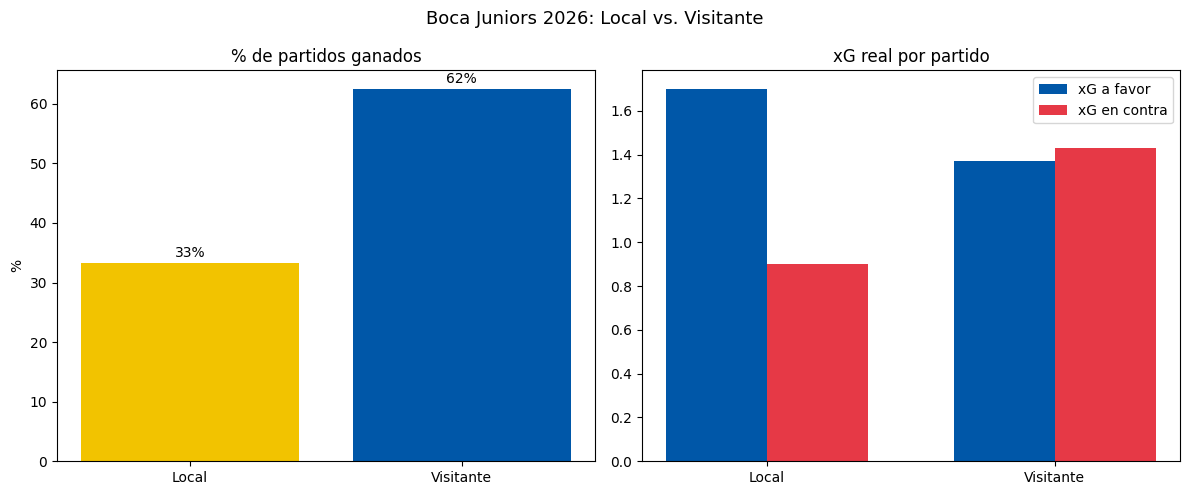

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

splits = ["Local", "Visitante"]
win_pct = xg_split.loc[splits, "win_pct"]
axes[0].bar(splits, win_pct, color=[BOCA_YELLOW, BOCA_BLUE])
axes[0].set_title("% de partidos ganados")
axes[0].set_ylabel("%")
for i, v in enumerate(win_pct):
    axes[0].text(i, v + 1, f"{v:.0f}%", ha="center")

x = np.arange(len(splits))
width = 0.35
xg_for = xg_split.loc[splits, "xg_for"]
xg_against = xg_split.loc[splits, "xg_against"]
axes[1].bar(x - width/2, xg_for, width, label="xG a favor", color=BOCA_BLUE)
axes[1].bar(x + width/2, xg_against, width, label="xG en contra", color=BOCA_RED)
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_title("xG real por partido")
axes[1].legend()

fig.suptitle("Boca Juniors 2026: Local vs. Visitante", fontsize=13)
fig.tight_layout()
plt.show()


## 5. Goleadores, asistencias y eficiencia (datos oficiales)

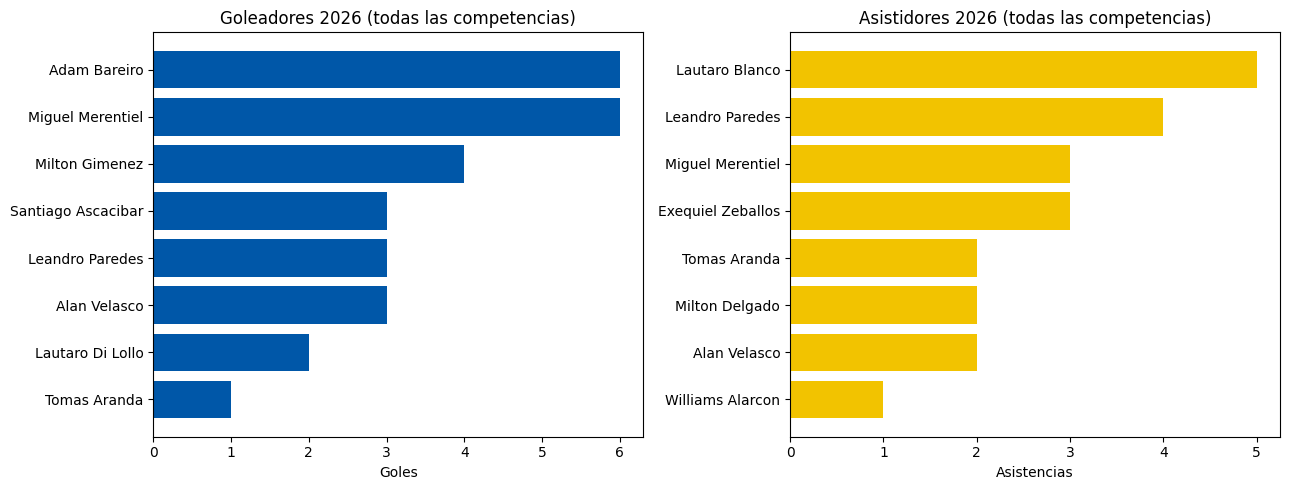

Nota: estos totales están verificados cruzando Wikipedia oficial con el Goal Log de FBref (coinciden al 100%).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_g = goals_official.sort_values("goals_total", ascending=False).head(8)
axes[0].barh(top_g["name"][::-1], top_g["goals_total"][::-1], color=BOCA_BLUE)
axes[0].set_title("Goleadores 2026 (todas las competencias)")
axes[0].set_xlabel("Goles")

top_a = assists_official.sort_values("assists_total", ascending=False).head(8)
axes[1].barh(top_a["name"][::-1], top_a["assists_total"][::-1], color=BOCA_YELLOW)
axes[1].set_title("Asistidores 2026 (todas las competencias)")
axes[1].set_xlabel("Asistencias")

fig.tight_layout()
plt.show()

print("Nota: estos totales están verificados cruzando Wikipedia oficial con el Goal Log de FBref (coinciden al 100%).")


## 6. ¿Cuándo marca Boca?

Usamos el Goal Log de FBref (30 goles con minuto exacto) para ver si hay un
patrón temporal — muchos equipos tienen tramos del partido donde son más
letales.


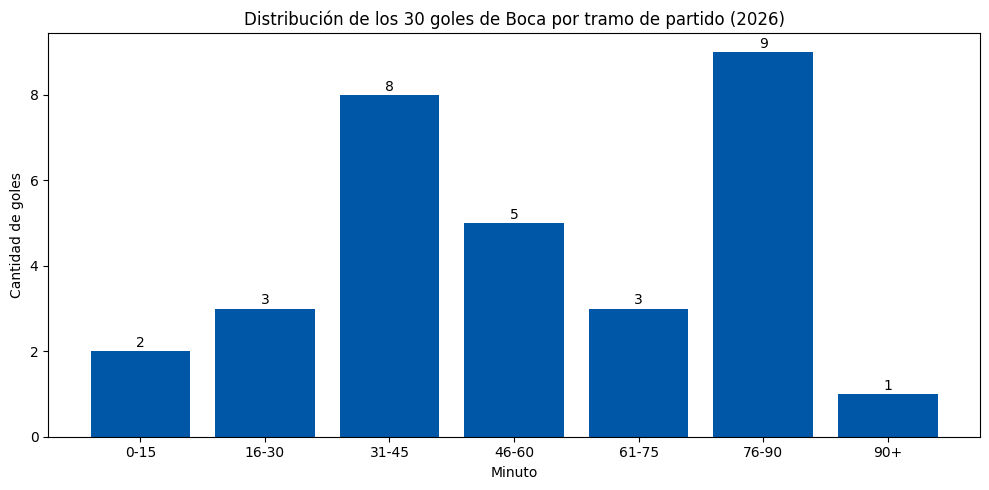

Boca marco 10 de sus 31 goles (32%) en los ultimos 15-20 minutos + descuento: un equipo que aparece en los finales de partido.


In [9]:
bins = [0, 15, 30, 45, 60, 75, 91, 130]
labels = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90", "90+"]
goals_by_match["minute_clean"] = goals_by_match["minute"].astype(str).str.extract(r"(\d+)").astype(int)
goals_by_match["bucket"] = pd.cut(goals_by_match["minute_clean"], bins=bins, labels=labels, right=True)

bucket_counts = goals_by_match["bucket"].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bucket_counts.index, bucket_counts.values, color=BOCA_BLUE)
ax.set_title("Distribución de los 30 goles de Boca por tramo de partido (2026)")
ax.set_xlabel("Minuto")
ax.set_ylabel("Cantidad de goles")
for i, v in enumerate(bucket_counts.values):
    ax.text(i, v + 0.1, str(v), ha="center")
fig.tight_layout()
plt.show()

late = bucket_counts[["76-90", "90+"]].sum()
print(f"Boca marco {late} de sus {bucket_counts.sum()} goles ({late/bucket_counts.sum():.0%}) en los ultimos",
      "15-20 minutos + descuento: un equipo que aparece en los finales de partido.")


## 7. Eficiencia de tiro: a favor vs. en contra

Con los datos de tiros partido a partido (FBref) podemos ver si Boca
convierte de acuerdo a las ocasiones que genera, o si depende de rachas de
eficacia/ineficacia.


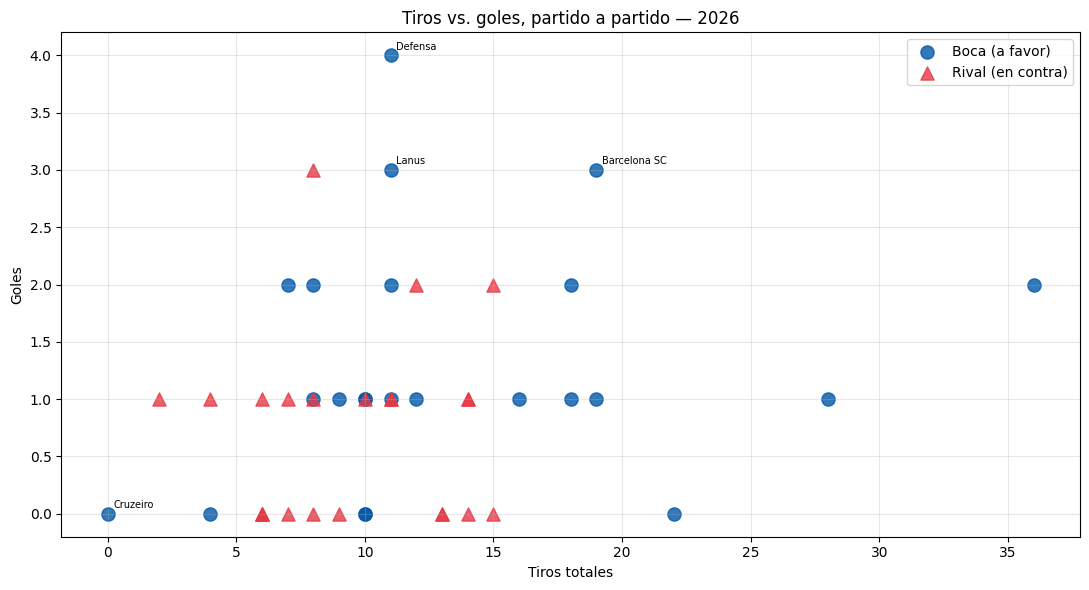

Dato llamativo: vs. Cruzeiro (2026-04-28) Boca no genero un solo tiro en todo el partido y perdio 0-1. No fue mala suerte con la definicion - fue una actuacion ofensiva practicamente nula.


In [10]:
ms = matches_shooting.dropna(subset=["shots_for"]).copy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(ms["shots_for"], ms["gf"], s=90, color=BOCA_BLUE, label="Boca (a favor)", alpha=0.8)
ax.scatter(ms["shots_against"], ms["ga"], s=90, color=BOCA_RED, label="Rival (en contra)", alpha=0.8, marker="^")

for _, row in ms.iterrows():
    if row["shots_for"] == 0 or row["gf"] >= 3:
        ax.annotate(row["opponent"], (row["shots_for"], row["gf"]), fontsize=7,
                    xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Tiros totales")
ax.set_ylabel("Goles")
ax.set_title("Tiros vs. goles, partido a partido — 2026")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

peor_partido = ms.loc[ms["shots_for"].idxmin()]
print(f"Dato llamativo: vs. {peor_partido['opponent']} ({peor_partido['date'].date()}) Boca no genero",
      "un solo tiro en todo el partido y perdio", f"{int(peor_partido['gf'])}-{int(peor_partido['ga'])}.",
      "No fue mala suerte con la definicion - fue una actuacion ofensiva practicamente nula.")


## 8. Disciplina

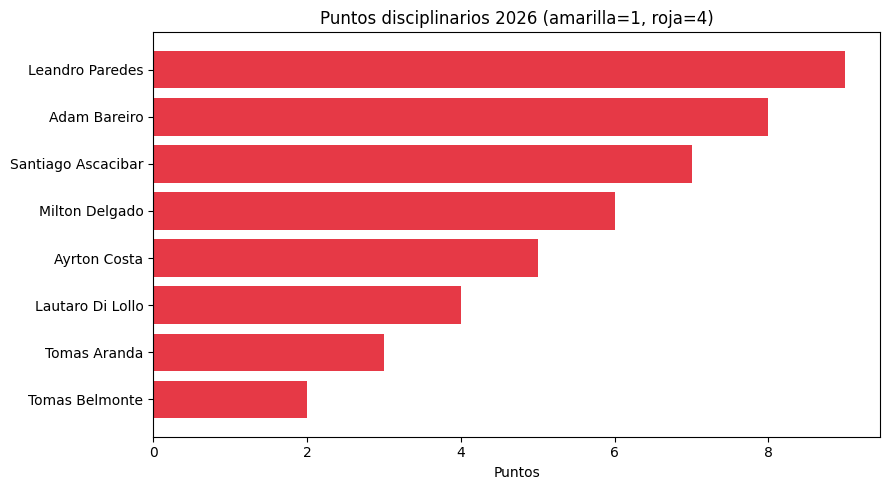

Jugadores actualmente en riesgo de sancion/con antecedentes de suspension:
              name  yellow_total  red_direct_total suspension
   Leandro Paredes             9                 0  1 partido
      Adam Bareiro             6                 0  1 partido
Santiago Ascacibar             3                 1 2 partidos
      Ayrton Costa             5                 0  1 partido


In [11]:
top_cards = cards_official.sort_values("disc_points_total", ascending=False).head(8)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_cards["name"][::-1], top_cards["disc_points_total"][::-1], color=BOCA_RED)
ax.set_title("Puntos disciplinarios 2026 (amarilla=1, roja=4)")
ax.set_xlabel("Puntos")
fig.tight_layout()
plt.show()

susp = cards_official[cards_official["suspension"] != "-"]
print("Jugadores actualmente en riesgo de sancion/con antecedentes de suspension:")
print(susp[["name", "yellow_total", "red_direct_total", "suspension"]].to_string(index=False))


## 9. Impacto de los refuerzos (antes vs. después)

Comparación de puntos y goles por partido antes y después de la llegada de
cada refuerzo. **Ojo:** para Montero, Villa y Lozano hay pocos o cero
partidos "después" todavía — recién debutan esta semana, y Lozano encima
se lesionó a los 25 días de llegar.


In [12]:
rows = []
for _, t in transfers.sort_values("arrival_date").iterrows():
    arrival = t["arrival_date"]
    before = played[played["date"] < arrival]
    after = played[played["date"] >= arrival]
    rows.append({
        "jugador": t["player"],
        "llegada": arrival.date(),
        "PJ antes": len(before),
        "PJ despues": len(after),
        "pts/partido antes": round(before["points"].mean(), 2) if len(before) else np.nan,
        "pts/partido despues": round(after["points"].mean(), 2) if len(after) else np.nan,
        "GF/partido antes": round(before["goals_for"].mean(), 2) if len(before) else np.nan,
        "GF/partido despues": round(after["goals_for"].mean(), 2) if len(after) else np.nan,
    })

impact_df = pd.DataFrame(rows)
print(impact_df.to_string(index=False))


           jugador    llegada  PJ antes  PJ despues  pts/partido antes  pts/partido despues  GF/partido antes  GF/partido despues
      Angel Romero 2026-01-01         0          27                NaN                 1.88               NaN                1.33
Santiago Ascacibar 2026-01-01         0          27                NaN                 1.88               NaN                1.33
      Adam Bareiro 2026-02-01         2          25               1.50                 1.93              1.00                1.36
    Leandro Lozano 2026-06-25        24           3               1.88                  NaN              1.33                1.33
    Alvaro Montero 2026-07-18        26           1               1.88                  NaN              1.35                1.00
   Sebastian Villa 2026-07-18        26           1               1.88                  NaN              1.35                1.00


## 10. Modelo predictivo: próximos 15 partidos del Clausura

Modelo tipo Poisson calibrado con:
- El **xG real** de Boca según localía (1.70 de local, 1.37 de visitante)
- La **fuerza de ataque/defensa relativa** de cada rival, calculada a partir
  de la tabla de posiciones completa


In [13]:
def prob_resultado(lambda_boca, lambda_rival, max_goles=6):
    probs = np.zeros((max_goles + 1, max_goles + 1))
    for i in range(max_goles + 1):
        for j in range(max_goles + 1):
            probs[i, j] = poisson.pmf(i, lambda_boca) * poisson.pmf(j, lambda_rival)
    return probs

league_avg_goals = standings["gf"].sum() / standings["pj"].sum()
standings["attack_strength"] = (standings["gf"] / standings["pj"]) / league_avg_goals
standings["defense_strength"] = (standings["gc"] / standings["pj"]) / league_avg_goals

boca_xg_local = xg_split.loc["Local", "xg_for"]
boca_xg_visitante = xg_split.loc["Visitante", "xg_for"]
boca_xga_local = xg_split.loc["Local", "xg_against"]
boca_xga_visitante = xg_split.loc["Visitante", "xg_against"]

liga_fixture = fixture[fixture["competition"].str.contains("Liga Profesional", na=False)].copy()

pred_rows = []
for _, row in liga_fixture.iterrows():
    match = standings[standings["team"] == row["opponent"]]
    if match.empty:
        continue
    opp_row = match.iloc[0]
    if row["venue"] == "H":
        lam_boca = boca_xg_local * opp_row["defense_strength"]
        lam_opp = boca_xga_local * opp_row["attack_strength"]
    else:
        lam_boca = boca_xg_visitante * opp_row["defense_strength"]
        lam_opp = boca_xga_visitante * opp_row["attack_strength"]

    m = prob_resultado(lam_boca, lam_opp)
    pw, pdw, pl = np.sum(np.tril(m, -1)), np.sum(np.diag(m)), np.sum(np.triu(m, 1))
    pred_rows.append({
        "fecha": row["date"].date(), "rival": row["opponent"], "loc": row["venue"],
        "P(gana Boca)": pw, "P(empate)": pdw, "P(pierde Boca)": pl,
    })

pred_df = pd.DataFrame(pred_rows)
print(pred_df.to_string(index=False, formatters={
    "P(gana Boca)": "{:.1%}".format, "P(empate)": "{:.1%}".format, "P(pierde Boca)": "{:.1%}".format,
}))


     fecha                  rival loc P(gana Boca) P(empate) P(pierde Boca)
2026-07-26      Deportivo Riestra   A        48.9%     35.3%          15.8%
2026-08-02      Newell's Old Boys   A        57.9%     19.8%          21.4%
2026-08-09        Velez Sarsfield   H        42.0%     28.6%          29.3%
2026-08-16               Platense   A        45.1%     29.1%          25.8%
2026-08-23            Racing Club   A        32.0%     25.5%          42.4%
2026-08-30                  Lanus   H        50.4%     25.5%          24.0%
2026-09-06 Gimnasia y Esgrima (M)   A        51.5%     22.9%          25.3%
2026-09-13  Central Cordoba (SdE)   H        72.9%     17.5%           8.9%
2026-09-20            San Lorenzo   A        34.9%     27.8%          37.3%
2026-10-04                  Union   H        54.3%     21.2%          24.0%
2026-10-11              Instituto   A        36.2%     24.8%          38.9%
2026-10-18           Talleres (C)   H        46.3%     27.8%          25.9%
2026-10-25  

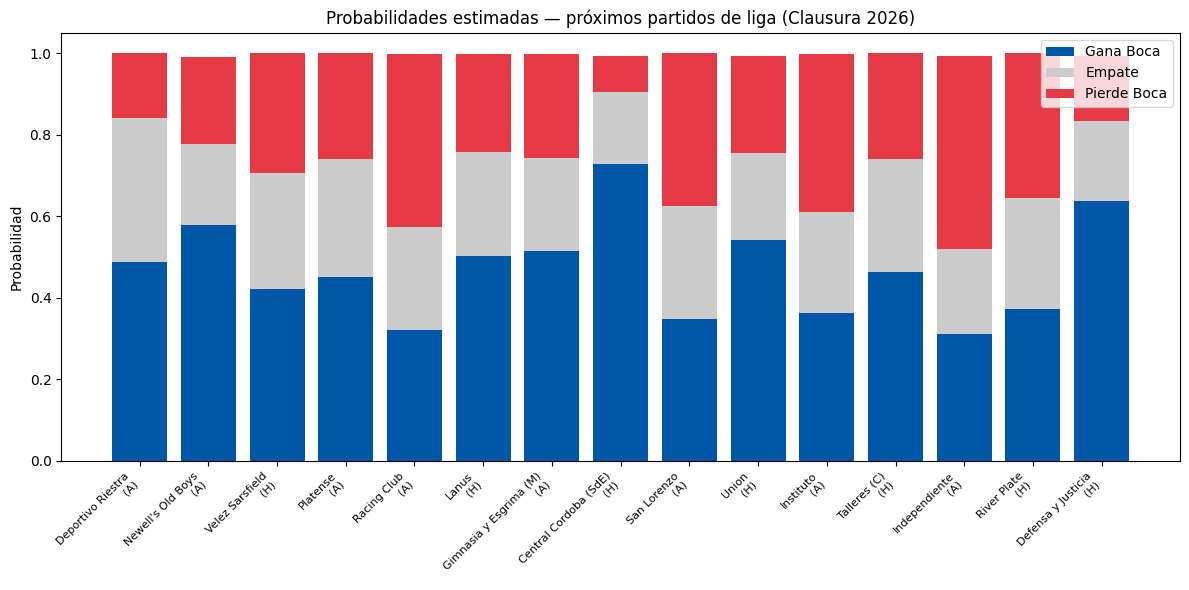

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pred_df))
ax.bar(x, pred_df["P(gana Boca)"], label="Gana Boca", color=BOCA_BLUE)
ax.bar(x, pred_df["P(empate)"], bottom=pred_df["P(gana Boca)"], label="Empate", color="#CCCCCC")
ax.bar(x, pred_df["P(pierde Boca)"],
       bottom=pred_df["P(gana Boca)"] + pred_df["P(empate)"], label="Pierde Boca", color=BOCA_RED)
ax.set_xticks(x)
ax.set_xticklabels([f"{r}\n({l})" for r, l in zip(pred_df["rival"], pred_df["loc"])],
                    rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Probabilidad")
ax.set_title("Probabilidades estimadas — próximos partidos de liga (Clausura 2026)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


## 11. Conclusiones y próximos pasos

**Hallazgos principales:**

1. Boca tiene un rendimiento notablemente **mejor de visitante que de
   local** esta temporada (63% vs 33% de victorias; 16 pts vs 14 pts pese
   a jugar dos partidos menos de visitante).
2. Boca es un **equipo de finales de partido**: buena parte de sus goles
   llegan en el último cuarto de hora, lo que sugiere fortaleza física/
   mental para partidos cerrados, pero también podría reflejar dificultad
   para dominar desde el arranque.
3. El partido vs. Cruzeiro (28/4) es un caso extremo: **cero tiros en 90
   minutos**, algo que no aparece en ningún otro partido de la temporada.
4. Los refuerzos de julio (Montero, Villa, Lozano) llegan en un momento de
   **racha de lesiones** en el plantel — el impacto real se va a poder
   medir recién con más partidos.
5. El modelo predictivo calibrado con xG real da probabilidades más
   conservadoras que un modelo ingenuo — refleja mejor la realidad de que
   Boca no es un candidato dominante este semestre.

**Próximos pasos sugeridos:**
- Actualizar `matches.csv` y `goals_by_match.csv` después de cada partido.
- Sumar minutos y stats de Montero/Villa/Lozano en cuanto debuten.
- Investigar la causa del bajo rendimiento como local.
- Sumar datos de córners y tarjetas por partido (no solo totales de
  temporada) para un análisis disciplinario más fino.
